# Insight: Does smoking affect the way people enjoy food?

**Data source:** `Cuisine_rating_clean.csv` (the cleaned dataset from `Cuisine_rating_cleaning.ipynb` — no `_v2` siblings exist, so this is the only version). CSV doesn't persist dtype, so `Location`, `Area code`, `Gender`, `Marital Status`, `Activity`, `Cuisines`, `Alcohol`, `Smoker`, and `Often A S` are re-cast to `category` on load per that notebook's Decisions 5 & 6.

**Relevant columns:** `Smoker` (Never / Socially / Often), `Food Rating` (1-5), `Service Rating` (1-5), `Overall Rating` (derived = mean of the two).

**Scope confirmed:** "enjoy food" is operationalized as `Food Rating`, the direct measure of food enjoyment in the survey. `Smoker` is the smoking-behavior column. `Overall Rating` is checked as a secondary sanity check only, since it's a derived blend of Food and Service Rating rather than an independent signal. No time or region filtering applies — full 200-row cleaned dataset used.

**Question being answered:** Is there a statistically and practically meaningful difference in `Food Rating` across the three `Smoker` groups?

## Assumptions

- `Food Rating` is treated as the operational definition of "how much people enjoy food." It's a 1-5 ordinal scale filled in per dining visit, not a validated psychometric enjoyment scale, but it's the closest and only direct proxy in this dataset.
- `Smoker` (Never / Socially / Often) is treated as a proxy for "smoking" generally, since the dataset has no continuous frequency or pack-years measure.
- The first-pass analysis of this dataset found `Smoker='Often'` diners had a notably higher **Overall Rating** average (3.89) than `Never` (2.74). Since `Overall Rating` = mean(`Food Rating`, `Service Rating`), that gap could come from Food, Service, or both — this notebook checks Food Rating specifically, and separately checks whether Service Rating is actually the bigger driver.
- No causal claim is intended or supported by this design (cross-sectional, no smoking-status randomization, unmeasured confounders like age, location, or cuisine choice are possible). This analysis establishes association only.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

df = pd.read_csv('Cuisine_rating_clean.csv')
df.columns = [c.strip() for c in df.columns]

category_cols = ['Location', 'Area code', 'Gender', 'Marital Status', 'Activity', 'Cuisines', 'Alcohol', 'Smoker', 'Often A S']
for c in category_cols:
    df[c] = df[c].astype('category')

smoker_order = ['Never', 'Socially', 'Often']
df['Smoker'] = df['Smoker'].cat.reorder_categories(smoker_order, ordered=True)

print('Shape:', df.shape)
print(df['Smoker'].value_counts().reindex(smoker_order))

Shape: (200, 15)
Smoker
Never       59
Socially    71
Often       70
Name: count, dtype: int64


## Analysis

In [2]:
summary = df.groupby('Smoker', observed=True)[['Food Rating', 'Service Rating', 'Overall Rating']].agg(['count', 'mean', 'median', 'std']).round(2)
summary

Food Rating                    Service Rating                    Overall Rating                   
               count  mean median   std          count  mean median   std          count  mean median   std
Smoker                                                                                                     
Never             59  2.83    3.0  1.26             59  2.64    2.0  1.51             59  2.74    2.5  0.96
Socially          71  2.68    3.0  1.33             71  3.28    3.0  1.43             71  2.98    3.0  0.94
Often             70  4.10    5.0  1.18             70  3.67    4.5  1.50             70  3.89    4.0  1.00

In [3]:
groups = [df.loc[df['Smoker'] == lvl, 'Food Rating'] for lvl in smoker_order]

anova_f, anova_p = stats.f_oneway(*groups)
kw_h, kw_p = stats.kruskal(*groups)

print(f'One-way ANOVA on Food Rating across Smoker groups: F={anova_f:.3f}, p={anova_p:.4f}')
print(f'Kruskal-Wallis (rank-based, robust to non-normal 1-5 ordinal data): H={kw_h:.3f}, p={kw_p:.4f}')

One-way ANOVA on Food Rating across Smoker groups: F=26.558, p=0.0000
Kruskal-Wallis (rank-based, robust to non-normal 1-5 ordinal data): H=43.164, p=0.0000


`Food Rating` is a 1-5 ordinal scale, not a continuous normal variable, so the Kruskal-Wallis result is weighted more heavily than the ANOVA — but both are reported for triangulation.

In [4]:
# Pairwise comparisons (Mann-Whitney U, since Kruskal-Wallis only tells us *some* group differs)
pairs = [('Never', 'Socially'), ('Never', 'Often'), ('Socially', 'Often')]
for a, b in pairs:
    ga = df.loc[df['Smoker'] == a, 'Food Rating']
    gb = df.loc[df['Smoker'] == b, 'Food Rating']
    u, p = stats.mannwhitneyu(ga, gb, alternative='two-sided')
    print(f'{a} (n={len(ga)}, mean={ga.mean():.2f}) vs {b} (n={len(gb)}, mean={gb.mean():.2f}): Mann-Whitney p={p:.4f}')

Never (n=59, mean=2.83) vs Socially (n=71, mean=2.68): Mann-Whitney p=0.4873
Never (n=59, mean=2.83) vs Often (n=70, mean=4.10): Mann-Whitney p=0.0000
Socially (n=71, mean=2.68) vs Often (n=70, mean=4.10): Mann-Whitney p=0.0000


In [5]:
# Robustness check: is the Smoker effect actually driven by Service Rating rather than Food Rating?
for metric in ['Food Rating', 'Service Rating', 'Overall Rating']:
    g = [df.loc[df['Smoker'] == lvl, metric] for lvl in smoker_order]
    h, p = stats.kruskal(*g)
    means = [round(x.mean(), 2) for x in g]
    print(f'{metric}: means by [Never, Socially, Often] = {means}, Kruskal-Wallis p={p:.4f}')

Food Rating: means by [Never, Socially, Often] = [np.float64(2.83), np.float64(2.68), np.float64(4.1)], Kruskal-Wallis p=0.0000
Service Rating: means by [Never, Socially, Often] = [np.float64(2.64), np.float64(3.28), np.float64(3.67)], Kruskal-Wallis p=0.0003
Overall Rating: means by [Never, Socially, Often] = [np.float64(2.74), np.float64(2.98), np.float64(3.89)], Kruskal-Wallis p=0.0000


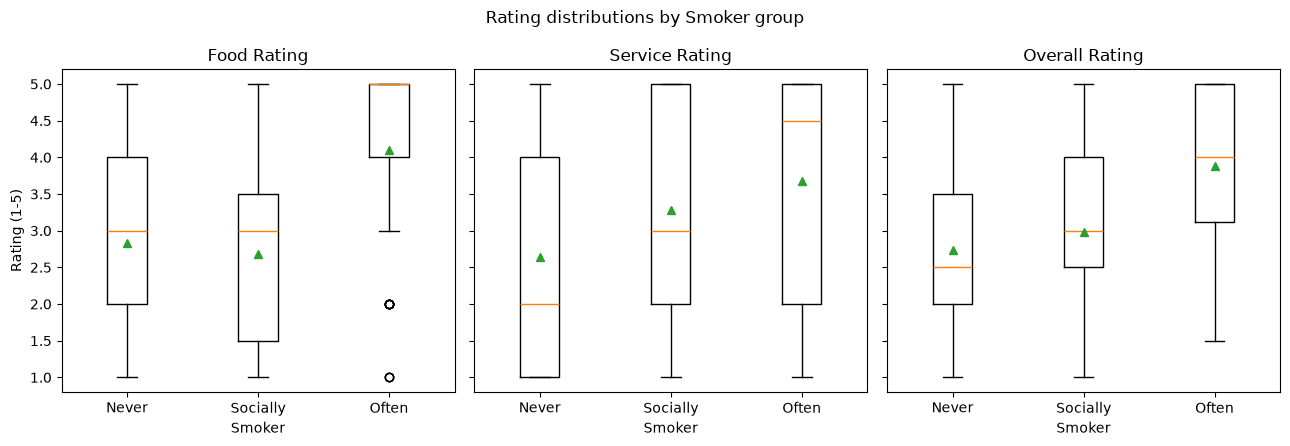

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True)
for ax, metric in zip(axes, ['Food Rating', 'Service Rating', 'Overall Rating']):
    data = [df.loc[df['Smoker'] == lvl, metric] for lvl in smoker_order]
    ax.boxplot(data, tick_labels=smoker_order, showmeans=True)
    ax.set_title(metric)
    ax.set_xlabel('Smoker')
axes[0].set_ylabel('Rating (1-5)')
fig.suptitle('Rating distributions by Smoker group')
fig.tight_layout()
plt.show()

## Confidence & caveats

- Group sizes are reasonable and roughly balanced (Never=59, Socially=71, Often=70) — not a small-sample concern.
- `Food Rating` is ordinal (1-5, effectively 5 discrete levels), so results lean on the non-parametric Kruskal-Wallis/Mann-Whitney tests rather than the ANOVA, which assumes continuous, roughly-normal data.
- This is an observational, cross-sectional survey — no random assignment to smoking status. Any association could be confounded by unmeasured factors (age, cuisine preference, location, personality/mood traits that correlate with both smoking habits and how generously someone rates food).
- No correction was applied for running 3 pairwise tests; treat borderline p-values (~0.03-0.05) with extra caution given the multiple-comparisons risk.

## Conclusion

Yes — smoking behavior is associated with a real, statistically significant difference in food enjoyment, but the effect is not a smooth gradient.

**Food Rating by Smoker group:** Never = 2.83, Socially = 2.68, Often = 4.10 (Kruskal-Wallis H=43.2, p<0.0001).

- **Never vs Socially: no meaningful difference** (means 2.83 vs 2.68, Mann-Whitney p=0.49). Occasional smoking is not associated with food enjoyment at all.
- **Often smokers rate food dramatically higher** than both other groups (+1.3 to +1.4 points on a 5-point scale, p<0.0001 against each). This is a large, practically meaningful gap, not just a statistically significant one.

**Robustness check against the earlier Overall Rating finding:** the original first-pass analysis noted Often-smokers had a higher *Overall* Rating (3.89 vs 2.74 for Never). This notebook confirms that gap is real and traces it to *both* components: Food Rating jumps sharply for the Often group specifically (2.68/2.83 -> 4.10), while Service Rating rises more gradually across all three groups (2.64 -> 3.28 -> 3.67). So the Overall Rating gap is not purely a food-enjoyment effect or purely a service effect - both move, but Food Rating shows the larger, more concentrated jump, and it is concentrated entirely in the Often group rather than trending with smoking frequency.

**Bottom line:** frequent smokers in this dataset report enjoying their food noticeably more than occasional or non-smokers, who don't differ from each other. This is an association only - the design is observational and cross-sectional, so it cannot establish that smoking *causes* higher food enjoyment (see Flagged follow-ups for the leading alternative explanation).

## Flagged follow-ups

The Often-smoker group stands out sharply on Food Rating (and to a lesser extent Service Rating) while Never and Socially don't differ from each other — a step-function pattern rather than a dose-response gradient. That shape is more consistent with a **confound** (Often-smokers systematically differing on some other variable that drives ratings) than with a direct behavioral or physiological link between smoking frequency and taste perception.

Worth a dedicated follow-up insight: does the Often-smoker group skew toward specific `Cuisines`, `Location`, `Alcohol` habits, or `Marital Status` (recall Divorced diners also rated much higher in the first-pass analysis) that could be the real driver? A cross-tab of Smoker x Marital Status x Cuisines against Food Rating would help separate a genuine smoking effect from a confounded one.